# When Simple Beats Sophisticated: Forecasting Spain's Peak Electricity Demand

A linear regression was **pre-registered** against a trivial "tomorrow's peak = today's peak" guess. The guess won by 32.8%. Diagnosing exactly why is the actual project, as well as the one pattern every method still shares (Weekends).

**Sections:** 1–2 Setup & Data Collection · 3 SQL Join · 4 EDA · 5 Features & Split · 6 Modelling ·
7 Evaluation & Diagnosis · 8 Charts & Export.

**Stack:** Python · pandas · scikit-learn · SQLite · matplotlib/seaborn · ENTSO-E · Open-Meteo (ERA5)

**Target:** tomorrow's daily *peak* demand, one number in MW.

**Honesty caveat:** trains on *actual* temperature; a real deployment would use *forecast* temperature.

## Section 1: Setup


In [1]:
#Section 1: Library Imports
import pandas as pd
import numpy as np
import sqlite3
!pip install -q entsoe-py
from entsoe import EntsoePandasClient
import requests
!pip install -q holidays
import holidays

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.1f}'.format)   # demand is in MW; 1 decimal is plenty
sns.set_style('whitegrid')

libraries = [pd, np, requests, holidays, sklearn, matplotlib, sns]

print("All libraries imported.")
for module in libraries:
    print(module.__name__, module.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.1 MB/s eta 0:00:00
All libraries imported.
pandas 2.2.2
numpy 2.0.2
requests 2.32.4
holidays 0.100
sklearn 1.6.1
matplotlib 3.10.0
seaborn 0.13.2


##Section 2: Data Collection

Two of the three sources are pulled here:

- **Demand:** hourly actual load for Spain from ENTSO-E (API token required), reduced to a daily peak.
- **Weather:** hourly temperature from Open-Meteo ERA5 (free, CC BY 4.0), reduced to daily max/min/mean (Only temp_mean is used in final model. See Section 5.).

Both are pulled in one timezone (Europe/Madrid) and in two blocks, 2017–2019 and 2022–2024.
2020–2021 is deliberately excluded (COVID disrupted the usual factors that drove demand).

`COUNTRY_CODE` is the swappable-pipeline knob: change one string to run the whole project on any ENTSO-E country.

In [2]:
#Section 2: Data Collection
##A. Pull electricity demand data (ENTSO-E) and reduce to daily peak
##B. Pull weather data (Open-Mateo ERA5) and reduce to daily temperature

##A. Pulling and electricity demand data to daily peak
COUNTRY_CODE = 'ES'
TIMEZONE = 'Europe/Madrid'
client = EntsoePandasClient(api_key="25f68329-a7ef-453e-8e5d-ec43e301da8b")
periods = [
    ('2017-01-01','2019-12-31'),
    ('2022-01-01','2024-12-31')
           ]
demand_frames = []
for start_str, end_str in periods:
  start = pd.Timestamp(start_str, tz=TIMEZONE)
  end = pd.Timestamp(end_str, tz =TIMEZONE)

  load = client.query_load(COUNTRY_CODE, start=start, end=end)
  demand_frames.append(load)
  print(f"Pulled {start_str} - {end_str}:{len(load)} rows")

demand_hourly = pd.concat(demand_frames)
demand_hourly = demand_hourly.rename(columns={'Actual Load':'load_mw'})
print(f"\nTotal hourly rows: {len(demand_hourly)}")
print(f"Span: {demand_hourly.index.min()} - {demand_hourly.index.max()}")

demand_daily = (
    demand_hourly
    .groupby(demand_hourly.index.normalize())['load_mw']
    .max()
    .reset_index()
)
demand_daily.columns=['date','peak_demand_mw']
demand_daily['date'] = demand_daily['date'].dt.tz_localize(None).dt.strftime('%Y-%m-%d')
demand_daily.to_csv('demand_daily_raw.csv', index=False)

print(f"")
print(demand_daily.head())
print(len(demand_daily))
print(f"Peak demand range: {demand_daily['peak_demand_mw'].min():.0f} "
        f"- {demand_daily['peak_demand_mw'].max():.0f} MW")


##B. Pulling and reducing electricity demand data to daily peak
###Call Open-Meteo archive API for hourly temp
LAT, LON = 40.4168, -3.7038

weather_frames= []
for start_str, end_str in periods:
  url = (
          "https://archive-api.open-meteo.com/v1/archive"
          f"?latitude={LAT}&longitude={LON}"
          f"&start_date={start_str}&end_date={end_str}"
          "&hourly=temperature_2m"
          f"&timezone={TIMEZONE.replace('/', '%2F')}"
      )
  resp = requests.get(url)
  resp.raise_for_status()
  data = resp.json()

  block = pd.DataFrame({
      'time':pd.to_datetime(data['hourly']['time']),
      'temp_c':data['hourly']['temperature_2m'],
  })
  weather_frames.append(block)
  print(f"Pulled weather {start_str} - {end_str}: {len(block)} hourly rows")

weather_hourly = pd.concat(weather_frames, ignore_index=True)

###Reducing hourly temperature to daily max, min, mean
weather_hourly['date'] = weather_hourly['time'].dt.strftime('%Y-%m-%d')

weather_daily = (
    weather_hourly
    .groupby('date')['temp_c']
    .agg(['max', 'min', 'mean'])
    .reset_index()
)
weather_daily.columns = ['date','temp_max','temp_min','temp_mean']
weather_daily.to_csv('weather_daily_raw.csv', index=False)

print(f"Daily weather rows: {len(weather_daily)}")
print(weather_daily.head())
print(f"Temp range: {weather_daily['temp_min'].min():.1f} - {weather_daily['temp_max'].max():.1f} °C")

demand_dates = set(demand_daily['date'])
weather_dates = set(weather_daily['date'])

print(f"demand_daily: {len(demand_dates)} unique dates")
print(f"weather_daily: {len(weather_dates)} unique dates")
print(f"Identical sets: {demand_dates == weather_dates}")

Pulled 2017-01-01 - 2019-12-31:26250 rows
Pulled 2022-01-01 - 2024-12-31:94889 rows

Total hourly rows: 121139
Span: 2017-01-01 00:00:00+01:00 - 2024-12-30 23:45:00+01:00

         date  peak_demand_mw
0  2017-01-01         29180.0
1  2017-01-02         34955.0
2  2017-01-03         36202.0
3  2017-01-04         35607.0
4  2017-01-05         34626.0
2189
Peak demand range: 23232 - 41015 MW
Pulled weather 2017-01-01 - 2019-12-31: 26280 hourly rows
Pulled weather 2022-01-01 - 2024-12-31: 26304 hourly rows
Daily weather rows: 2191
         date  temp_max  temp_min  temp_mean
0  2017-01-01       3.0      -4.3       -0.8
1  2017-01-02       6.3      -1.8        1.3
2  2017-01-03       9.9      -0.1        4.1
3  2017-01-04      12.8       0.8        5.3
4  2017-01-05      12.1       1.5        5.2
Temp range: -4.4 - 41.3 °C
demand_daily: 2189 unique dates
weather_daily: 2191 unique dates
Identical sets: False


##Section 3: Data Preparation

**Builds the calendar source** (day-of-week, month, season, holiday, weekend, all derived from the date, so zero leakage risk), then joins all three sources in SQLite with a real three-source `INNER JOIN`
on a daily date key.

**On the SQL Join:** the data is small, pandas could do this join. SQLite is here for the
relational/production approach as SQL is a near-universal tool used. The real work is upstream: aligning three sources onto a consistent daily key.

**Result:** 2,189 joined rows, zero missing values (the inner join drops the ~2 boundary days that don't
appear in all three tables).

In [3]:
#Section 3: Data Preparation
#A. Calendar Features
es_holidays = holidays.Spain(years=range(2017, 2025))
cal = pd.DataFrame({'date':pd.to_datetime(demand_daily['date'])})

cal['dayofweek'] = cal['date'].dt.dayofweek
cal['month'] = cal['date'].dt.month
cal['is_weekend'] = (cal['dayofweek'] >= 5).astype(int)
cal['is_holiday'] = cal['date'].dt.date.map(lambda d: 1 if d in es_holidays else 0)

def month_to_season(m):
  if m in (12,1,2): return 'winter'
  if m in (3,4,5): return 'spring'
  if m in (6,7,8): return 'summer'
  return 'autumn'
cal['season'] = cal['month'].map(month_to_season)

calendar_daily = cal.copy()
calendar_daily['date'] = calendar_daily['date'].dt.strftime('%Y-%m-%d')

calendar_daily.to_csv('calendar_daily_raw.csv', index=False)

print(f"Calendar rows: {len(calendar_daily)}")
print(calendar_daily.head())
print(f"Holidays flagged: {calendar_daily['is_holiday'].sum()}")

##B. SQL Join
###The combination of three datasets is done via SQLite.
conn = sqlite3.connect('electricity.db')
demand_daily.to_sql('demand', conn, if_exists = 'replace', index = False)
weather_daily.to_sql('weather', conn, if_exists = 'replace', index = False)
calendar_daily.to_sql('calendar', conn, if_exists = 'replace', index = False)

print("Three tables loaded into electricity.db: demand, weather, and calendar")

join_query = """
      SELECT
          d.date           AS date,
          d.peak_demand_mw AS peak_demand_mw,
          w.temp_max       AS temp_max,
          w.temp_min       AS temp_min,
          w.temp_mean      AS temp_mean,
          c.dayofweek      AS dayofweek,
          c.month          AS month,
          c.season         AS season,
          c.is_holiday     AS is_holiday,
          c.is_weekend     AS is_weekend
      FROM        demand   AS d
      INNER JOIN  weather  AS w  ON d.date = w.date
      INNER JOIN  calendar AS c  ON d.date = c.date
      ORDER BY    d.date;
  """

df = pd.read_sql_query(join_query,conn)
df['date'] = pd.to_datetime(df['date'])
conn.close()

print(f"Joined rows (days kept by the inner join): {len(df)}")
print(f"Date span: {df['date'].min().date()} - {df['date'].max().date()}")
print(f"Any missing values?\n{df.isna().sum()}")
df.head()


Calendar rows: 2189
         date  dayofweek  month  is_weekend  is_holiday  season
0  2017-01-01          6      1           1           0  winter
1  2017-01-02          0      1           0           0  winter
2  2017-01-03          1      1           0           0  winter
3  2017-01-04          2      1           0           0  winter
4  2017-01-05          3      1           0           0  winter
Holidays flagged: 53
Three tables loaded into electricity.db: demand, weather, and calendar
Joined rows (days kept by the inner join): 2189
Date span: 2017-01-01 - 2024-12-30
Any missing values?
date              0
peak_demand_mw    0
temp_max          0
temp_min          0
temp_mean         0
dayofweek         0
month             0
season            0
is_holiday        0
is_weekend        0
dtype: int64


,date,peak_demand_mw,temp_max,temp_min,temp_mean,dayofweek,month,season,is_holiday,is_weekend
0,2017-01-01,29180.0,3.0,-4.3,-0.8,6,1,winter,0,1
1,2017-01-02,34955.0,6.3,-1.8,1.3,0,1,winter,0,0
2,2017-01-03,36202.0,9.9,-0.1,4.1,1,1,winter,0,0
3,2017-01-04,35607.0,12.8,0.8,5.3,2,1,winter,0,0
4,2017-01-05,34626.0,12.1,1.5,5.2,3,1,winter,0,0


## Section 4: Exploratory Analysis

Plots daily peak demand against daily mean temperature to motivate the two-sided (U-shaped) demand intuition.
EDA runs *after* the join on purpose: the demand–temperature relationship only exists once the sources are aligned on a common day. Note: This scatter motivates the modelling, but the later error analysis contradicted the prediction that error would concentrate at the temperature extremes.

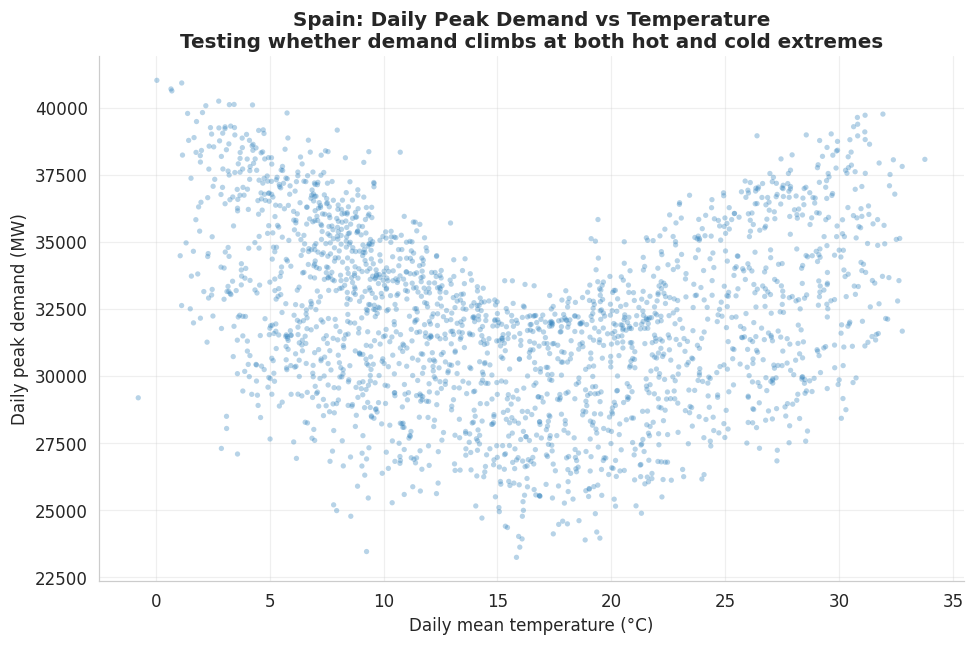

In [10]:
#Section 4: Exploratory Analysis
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

C_BASELINE = '#9ecae1'
C_LINEAR   = '#3182bd'
C_NONLIN   = '#e6772e'

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['temp_mean'], df['peak_demand_mw'],
           s=12, alpha=0.35, color=C_LINEAR, edgecolor='none')
ax.set_xlabel('Daily mean temperature (°C)')
ax.set_ylabel('Daily peak demand (MW)')
ax.set_title('Spain: Daily Peak Demand vs Temperature\n'
             'Testing whether demand climbs at both hot and cold extremes')
plt.tight_layout()
plt.savefig('chart1_ushape_scatter.png')
plt.show()

##Section 5: Feature Engineering & Split

Turns the joined table into model inputs (X) and a **next-day target** (Y), then splits by time.

- **Target shift:** each row's features (today) are lined up against **tomorrow's** peak. The shift is done
  **within each period** (`groupby('period').shift`) so the 2019-2022 COVID gap can't leak one block's edge into the next.
- **Features (7):** `temp_mean`, `prev_day_peak`, `is_weekend`, `is_holiday`, and three season dummies
  (autumn dropped as baseline).
- **Leakage check:** highest feature–target correlation is `prev_day_peak` at 0.4, signal, not leakage.
- **Chronological split:** train on **1,821 days** (2017–2023), test on the held-out **364 days of 2024**.
  Never shuffled (shuffling a time series leaks the future into the past).

In [5]:
#Section 5: Feature Enginerring and Split
##A. Building Model Inputs and Leakage Check
###Next Day Target
df = df.sort_values('date').reset_index(drop=True)
df['period'] = (df['date'].dt.year >= 2022).astype(int)
df['target_next_day_peak'] = df.groupby('period')['peak_demand_mw'].shift(-1)
df['prev_day_peak'] = df.groupby('period')['peak_demand_mw'].shift(1)
df_model = df.dropna(subset=['target_next_day_peak', 'prev_day_peak']).copy()

print(f"Rows before shift cleanup: {len(df)}")
print(f"Rows after dropping shift-edge NaNs: {len(df_model)}")

###Picking Feature Columns
df_model = pd.get_dummies(
    df_model,
    columns=['season'],
    drop_first=True
)

feature_col = [
      'temp_mean',
      'prev_day_peak',
      'is_weekend', 'is_holiday',
  ] + [c for c in df_model.columns if c.startswith('season_')]

X = df_model[feature_col]
Y = df_model['target_next_day_peak']
print("Features Used:")
for c in feature_col:
  print(f"-{c}")
print(f"\nX Shape: {X.shape} | y length: {len(Y)}")

###Leakage Check
leak_check = X.copy()
leak_check['__target__'] = Y.values
corrs = leak_check.corr(numeric_only=True)['__target__'].drop('__target__')

print("Feature correlation with the target (leakage would show as near +/-1.0):")
print(corrs.sort_values(ascending=False))

##B. Chronological Train/Test Split
###Split on Date Cutoff
split_date = pd.Timestamp('2024-01-01')

train_mask = df_model['date'] < split_date
test_mask = df_model['date'] >= split_date

X_train, Y_train = X[train_mask], Y[train_mask]
X_test, Y_test = X[test_mask], Y[test_mask]

print(f"Train rows: {len(X_train)} "
       f"({df_model.loc[train_mask, 'date'].min().date()} - "
       f"{df_model.loc[train_mask, 'date'].max().date()})")
print(f"Test rows:  {len(X_test)} "
       f"({df_model.loc[test_mask, 'date'].min().date()} - "
       f"{df_model.loc[test_mask, 'date'].max().date()})")


Rows before shift cleanup: 2189
Rows after dropping shift-edge NaNs: 2185
Features Used:
-temp_mean
-prev_day_peak
-is_weekend
-is_holiday
-season_spring
-season_summer
-season_winter

X Shape: (2185, 7) | y length: 2185
Feature correlation with the target (leakage would show as near +/-1.0):
prev_day_peak    0.4
season_winter    0.3
season_summer    0.1
is_holiday      -0.1
temp_mean       -0.1
is_weekend      -0.2
season_spring   -0.3
Name: __target__, dtype: float64
Train rows: 1821 (2017-01-02 - 2023-12-31)
Test rows:  364 (2024-01-01 - 2024-12-29)


##Section 6: Modeling

Fits one **linear regression** (chosen for interpretable MW-denominated coefficients), then runs a **lag-only ablation** to test whether the extra features help or hurt.

- **Key coefficient:** `prev_day_peak = +0.3`. The model damps yesterday's signal, where the naive baseline effectively uses it at **1.0**. This single fact is why the model loses (confirmed in Section 7).
- **Lag-only ablation:** MAE 2,211 MW worse than the full model (2,078), so the features help slightly. The problem isn't the features; it's the dampening.

In [6]:
#Section 6: Modeling
##Training the Linear Regression
model = LinearRegression()
model.fit(X_train, Y_train)

coefs = pd.Series(model.coef_, index = X_train.columns).sort_values()

print("Linear regression coefficients (MW per one-unit change in feature):")
print(coefs)
print(f"\nIntercept: {model.intercept_:.0f} MW")

##Ablation: model using ONLY prev_day_peak
# Checks whether the other 6 features help or hurt.
X_train_lag = X_train[['prev_day_peak']]
X_test_lag  = X_test[['prev_day_peak']]

model_lag = LinearRegression()
model_lag.fit(X_train_lag, Y_train)

Y_pred_lag = model_lag.predict(X_test_lag)
mae_lag = mean_absolute_error(Y_test, Y_pred_lag)

print(f"Lag-only model MAE: {mae_lag:.0f} MW")
print(f"  Full model MAE:   2078 MW  (all 7 features)")
print(f"  Naive baseline:   1565 MW  (tomorrow = today)")

Linear regression coefficients (MW per one-unit change in feature):
is_holiday      -1863.5
is_weekend      -1359.8
season_spring    -714.5
temp_mean         -58.6
prev_day_peak       0.3
season_winter    1523.4
season_summer    1787.2
dtype: float64

Intercept: 24491 MW
Lag-only model MAE: 2211 MW
  Full model MAE:   2078 MW  (all 7 features)
  Naive baseline:   1565 MW  (tomorrow = today)


##Section 7: Evaluation

Scores the model against the baseline, slices the errors, and runs one non-linear diagnostic.

**Headline:**
- **Baseline MAE 1,565 MW** vs **Linear MAE 2,078 MW**. The trivial guess outperforms by 513 MW or 32.8%.
- **Non-linear** (gradient boosting) **MAE 1,872 MW**. Beats linear by 206 MW, baseline still outperforms by 307 MW. So the ceiling is the lag signal, not model shape.

**Secondary findings:**
- **Weekends are structurally harder but not equal** Baseline degrades most (1,305 - 2,214 MW, +69.6%), linear regression less (1,927 - 2,456 MW, +27.5%), and non-linear least by far (1,802 - 2,046 MW, +13.5%). Unlike the overall result, a more flexible model measurably helps here, this is the one place added model sophistication earned its keep.
- The pre-registered error spikes at temperature extremes hypothesis is contradicted. The *mild* band (12–20 °C) was worst off (2,239 MW), the *hot* band best (1,479 MW).

In [7]:
#Section 7: Evaluation
##A. Test Set Score
###The Naive Baseline
naive_pred = df_model.loc[test_mask,'peak_demand_mw'].values
naive_mae = mean_absolute_error(Y_test, naive_pred)
naive_rmse = mean_squared_error(Y_test, naive_pred)**0.5

print(f"Baseline (Naive Persistence):")
print(f"MAE: {naive_mae:.0f} MW")
print(f"RMSE: {naive_rmse:.0f} MW")

###Model Scored Side by Side With Baseline
Y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test,Y_pred)
rmse = mean_squared_error(Y_test,Y_pred)**0.5
print(f"Model (Linear Regression):")
print(f"MAE: {mae:.0f} MW")
print(f"RMSE: {rmse:.0f} MW")
print(f"RMSE - MAE Gap: {rmse - mae:.0f} MW")
print(f"MAE as % of mean peak demand: {100*mae / Y_test.mean():.1f}%")

improvement_mae = naive_mae - mae
print(f"\nModel v Baseline:")
verb = "loses to" if improvement_mae < 0 else "beats"
direction = "higher" if improvement_mae < 0 else "lower"
print(f"Model {verb} naive by {abs(improvement_mae):.0f} MW on MAE "
      f"({abs(100 * improvement_mae / naive_mae):.1f}% {direction} error)")

##B. Error Analysis
results = pd.DataFrame({
      'date':      df_model.loc[test_mask, 'date'].values,
      'temp_mean': X_test['temp_mean'].values,
      'is_weekend':X_test['is_weekend'].values,
      'is_holiday':X_test['is_holiday'].values,
      'actual':    Y_test.values,
      'predicted': Y_pred,
  })
results['error'] = results['actual'] - results['predicted']
results['abs_error'] = results['error'].abs()
print(results.head())

###Error by Temperature Band
bands = pd.cut(results['temp_mean'],
                 bins=[-100, 5, 12, 20, 28, 100],
                 labels=['<5°C (very cold)', '5-12°C (cold)',
                         '12-20°C (mild)', '20-28°C (warm)', '>28°C (hot)'])
by_band = results.groupby(bands,observed=True)['abs_error'].agg(['mean','std','count'])
by_band.columns = ['mean_abs_error_MW','std_abs_error_MW','n_days']
print("Average miss by temperature band:")
print(by_band)

###Error by Season and Day Type
results['month'] = pd.to_datetime(results['date']).dt.month
results['season'] = results['month'].map(
    lambda m: 'winter' if m in (12,1,2) else
    'spring' if m in (3,4,5) else
    'summer' if m in (6,7,8) else 'autumn')
print("Average miss by season:")
print(results.groupby('season')['abs_error'].mean())

###Naive baseline error, split weekend vs weekday
results['naive_pred'] = naive_pred
results['naive_abs_error'] = (results['actual'] - results['naive_pred']).abs()

wk_baseline = results.groupby('is_weekend')['naive_abs_error'].mean()
print("\nNaive baseline miss, Weekend v Weekday:")
print(wk_baseline)

print("\nAverage Miss, Holidays v Normal:")
print(results.groupby('is_holiday')['abs_error'].mean())

##Non-linear test: does capturing the U-shape close the gap to the baseline?
from sklearn.ensemble import HistGradientBoostingRegressor

model_nl = HistGradientBoostingRegressor(
    max_iter=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
model_nl.fit(X_train, Y_train)

Y_pred_nl = model_nl.predict(X_test)
mae_nl  = mean_absolute_error(Y_test, Y_pred_nl)
rmse_nl = mean_squared_error(Y_test, Y_pred_nl)**0.5

wk_model = results.groupby('is_weekend')['abs_error'].mean()

results['nl_abs_error'] = (results['actual'] - Y_pred_nl).abs()
wk_nonlinear = results.groupby('is_weekend')['nl_abs_error'].mean()

print("\nWeekend split — all three methods (MAE, MW):")
print(f"{'':12}{'Weekday':>10}{'Weekend':>10}{'Gap':>10}{'Gap %':>10}")
for name, series in [('Baseline', wk_baseline), ('Linear', wk_model), ('Non-linear', wk_nonlinear)]:
    wd, we = series.loc[0], series.loc[1]
    gap = we - wd
    gap_pct = 100 * gap / wd
    print(f"{name:12}{wd:10.0f}{we:10.0f}{gap:10.0f}{gap_pct:9.1f}%")

print("\nThree-way comparison (MAE):")
print(f"  Naive baseline:      {naive_mae:.0f} MW  (tomorrow = today)")
print(f"  Linear model:        {mae:.0f} MW")
print(f"  Non-linear model:    {mae_nl:.0f} MW")
print(f"\n  Non-linear vs baseline: {mae_nl - naive_mae:+.0f} MW "
      f"({'beats baseline' if mae_nl < naive_mae else 'still loses to baseline'})")
print(f"  Non-linear vs linear:   {mae_nl - mae:+.0f} MW "
      f"({'improves on linear' if mae_nl < mae else 'worse than linear'})")

Baseline (Naive Persistence):
MAE: 1565 MW
RMSE: 2181 MW
Model (Linear Regression):
MAE: 2078 MW
RMSE: 2616 MW
RMSE - MAE Gap: 538 MW
MAE as % of mean peak demand: 6.6%

Model v Baseline:
Model loses to naive by 513 MW on MAE (32.8% higher error)
        date  temp_mean  is_weekend  is_holiday  actual  predicted   error  \
0 2024-01-01        5.0           0           1 33700.0    31573.4  2126.6   
1 2024-01-02        5.5           0           0 33000.0    33001.6    -1.6   
2 2024-01-03       10.6           0           0 33192.0    34302.2 -1110.2   
3 2024-01-04        9.4           0           0 30460.0    34186.0 -3726.0   
4 2024-01-05        6.6           0           0 28872.0    34401.3 -5529.3   

   abs_error  
0     2126.6  
1        1.6  
2     1110.2  
3     3726.0  
4     5529.3  
Average miss by temperature band:
                  mean_abs_error_MW  std_abs_error_MW  n_days
temp_mean                                                    
<5°C (very cold)             2143.4 

##Section 8: Communication & Delivery

Four charts each arguing one point, plus canonical CSV exports.

1. **U-Shape Scatter:** The Demand vs Temperature Motivation.
2. **Linear Model Behaviour:** Predicted vs Actual Over The Test Year, plus the error distribution.
3. **Weekend Gap:** The Finding Chart: Both baseline and model miss harder on weekends.
4. **Three-way MAE:**  The Honesty Chart, Baseline 1,565 · Linear 2,078 · Non-Linear 1,872. Both model bars sit above the baseline line.

Exports `data_aligned.csv` (model-ready data) and `results_summary.csv` (headline metrics), so the repo reproduces without re-running any API.

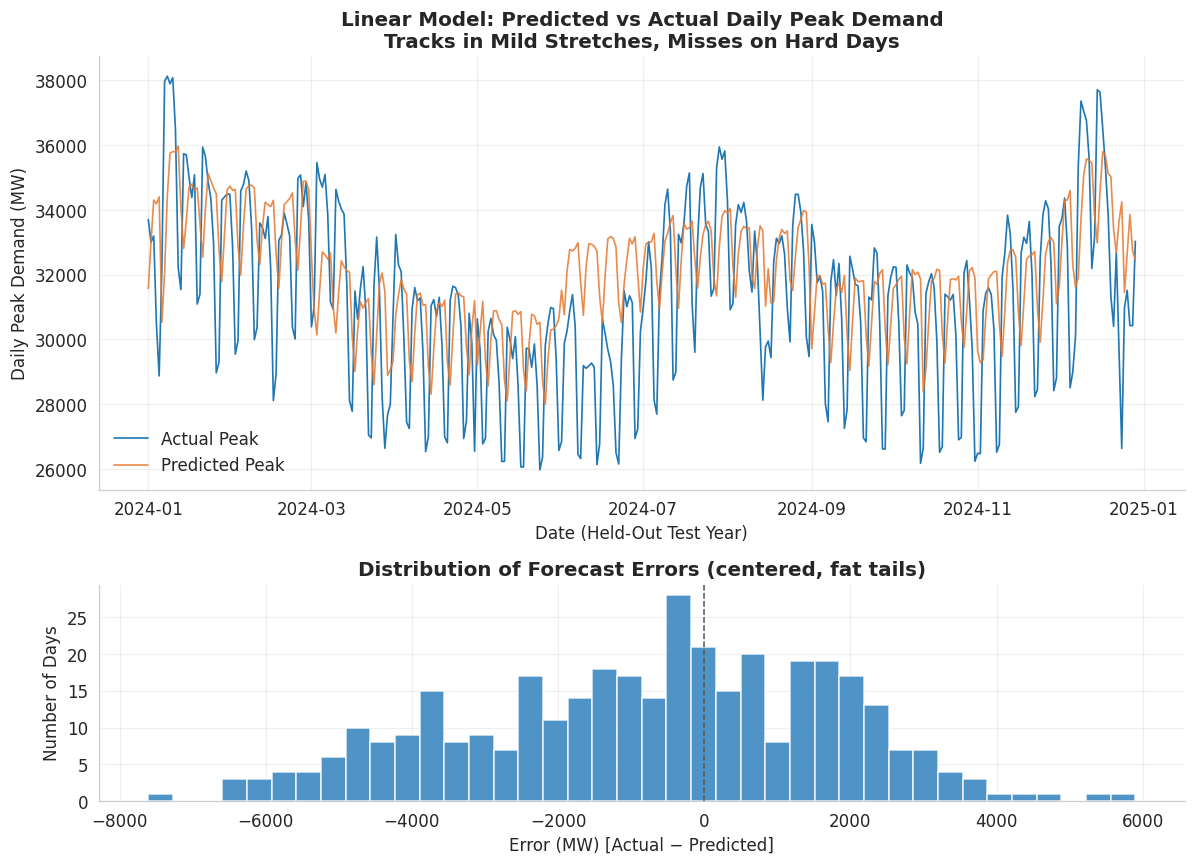


Weekend v Weekday MAE (all three methods):
  Baseline:   1305 -> 2214
  Linear:     1927 -> 2456
  Non-linear: 1802 -> 2046


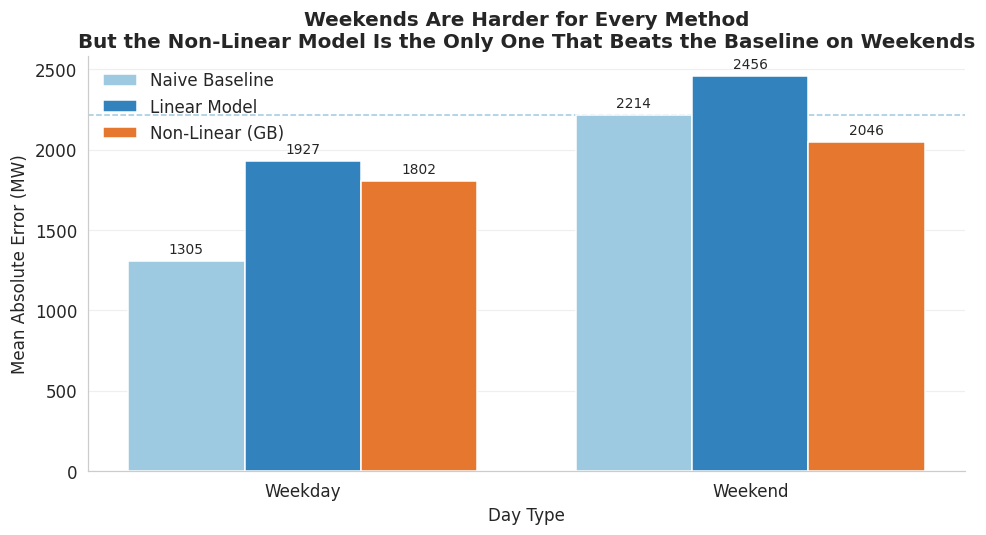

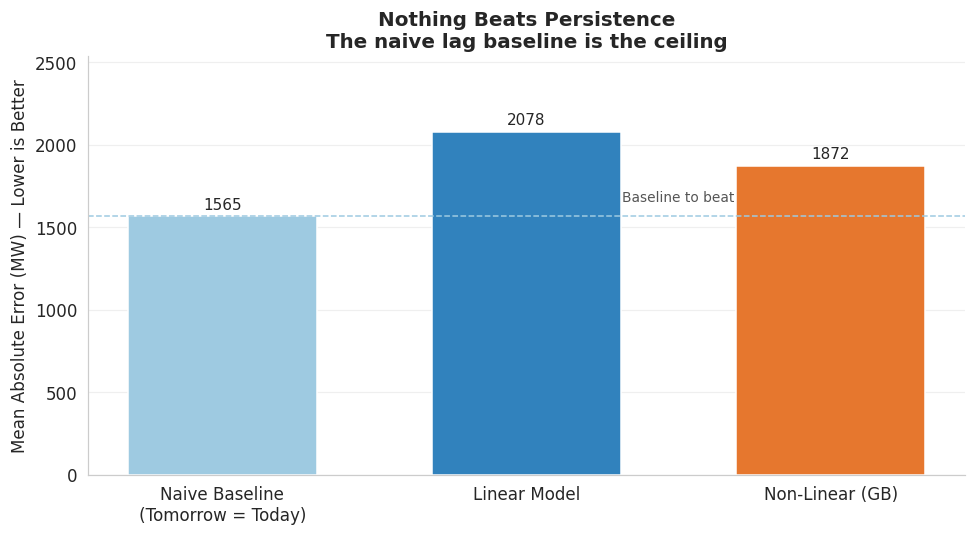

Exported: data_aligned.csv, results_summary.csv
                    metric  value
0          baseline_MAE_MW 1565.0
1            linear_MAE_MW 2078.0
2         nonlinear_MAE_MW 1872.0
3           linear_RMSE_MW 2616.0
4  model_minus_baseline_MW  513.0
5   linear_MAE_pct_of_mean    6.6
6             n_train_days 1821.0
7              n_test_days  364.0


In [11]:
#Section 8: Visualization
##A. Charts
###Chart 2: Linear Model Behaviour: Predicted-vs-Actual + Error Distribution
test_dates = pd.to_datetime(results['date'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8),
                                gridspec_kw={'height_ratios': [2, 1]})

####Top: Predicted V Actual Over the Held out Test Year
ax1.plot(test_dates, results['actual'], label='Actual Peak',
         linewidth=1.1)
ax1.plot(test_dates, results['predicted'], label='Predicted Peak',
         linewidth=1.1, color=C_NONLIN, alpha=0.85)
ax1.set_xlabel('Date (Held-Out Test Year)')
ax1.set_ylabel('Daily Peak Demand (MW)')
ax1.set_title('Linear Model: Predicted vs Actual Daily Peak Demand\n'
              'Tracks in Mild Stretches, Misses on Hard Days')
ax1.legend(frameon=False)

####Bottom: Distribution of Signed Errors
ax2.hist(results['error'], bins=40, color=C_LINEAR, alpha=0.85)
ax2.axvline(0, linestyle='--', linewidth=1, color='#555')
ax2.set_xlabel('Error (MW) [Actual − Predicted]')
ax2.set_ylabel('Number of Days')
ax2.set_title('Distribution of Forecast Errors (centered, fat tails)')

plt.tight_layout()
plt.savefig('chart2_linear_behaviour.png')
plt.show()

###Chart 3: Weekend Gap
wk_model     = results.groupby('is_weekend')['abs_error'].mean()
wk_baseline  = results.groupby('is_weekend')['naive_abs_error'].mean()
wk_nonlinear = results.groupby('is_weekend')['nl_abs_error'].mean()
print("\nWeekend v Weekday MAE (all three methods):")
print(f"  Baseline:   {wk_baseline.loc[0]:.0f} -> {wk_baseline.loc[1]:.0f}")
print(f"  Linear:     {wk_model.loc[0]:.0f} -> {wk_model.loc[1]:.0f}")
print(f"  Non-linear: {wk_nonlinear.loc[0]:.0f} -> {wk_nonlinear.loc[1]:.0f}")

labels = ['Weekday', 'Weekend']
baseline_vals  = [wk_baseline.loc[0], wk_baseline.loc[1]]
linear_vals    = [wk_model.loc[0], wk_model.loc[1]]
nonlinear_vals = [wk_nonlinear.loc[0], wk_nonlinear.loc[1]]

x = np.arange(len(labels)); width = 0.26
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, baseline_vals,  width, label='Naive Baseline',    color=C_BASELINE)
b2 = ax.bar(x,         linear_vals,    width, label='Linear Model',      color=C_LINEAR)
b3 = ax.bar(x + width, nonlinear_vals, width, label='Non-Linear (GB)',   color=C_NONLIN)

ax.axhline(wk_baseline.loc[1], linestyle='--', linewidth=1, color=C_BASELINE, zorder=0)

ax.set_ylabel('Mean Absolute Error (MW)')
ax.set_xlabel('Day Type')
ax.set_title('Weekends Are Harder for Every Method\n'
             'But the Non-Linear Model Is the Only One That Beats the Baseline on Weekends')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(frameon=False)
ax.bar_label(b1, fmt='%.0f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.0f', padding=3, fontsize=9)
ax.bar_label(b3, fmt='%.0f', padding=3, fontsize=9)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('chart3_weekend_gap.png')
plt.show()

###Chart 4: Three Way MAE (Baseline / Linear / Non-Linear)
names = ['Naive Baseline\n(Tomorrow = Today)', 'Linear Model', 'Non-Linear (GB)']
maes  = [naive_mae, mae, mae_nl]
colors = [C_BASELINE, C_LINEAR, C_NONLIN]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, maes, color=colors, width=0.62)

ax.set_ylabel('Mean Absolute Error (MW) — Lower is Better')
ax.set_title('Nothing Beats Persistence\n'
             'The naive lag baseline is the ceiling')
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=10)

ax.axhline(naive_mae, linestyle='--', linewidth=1, color=C_BASELINE, zorder=1)
ax.annotate('Baseline to beat',
            xy=(0, naive_mae), xytext=(1.5, naive_mae + 90),
            fontsize=9, color='#555', ha='center')

ax.set_ylim(0, max(maes) * 1.22)
ax.grid(axis='x', visible=False)   # vertical gridlines add nothing on a bar chart
plt.tight_layout()
plt.savefig('chart4_three_way_mae.png')
plt.show()

##B. Exporting Canonical Dataset
df_model.to_csv('data_aligned.csv', index=False)
results_summary = pd.DataFrame({
    'metric': [
        'baseline_MAE_MW', 'linear_MAE_MW', 'nonlinear_MAE_MW',
        'linear_RMSE_MW', 'model_minus_baseline_MW',
        'linear_MAE_pct_of_mean', 'n_train_days', 'n_test_days',
    ],
    'value': [
        round(naive_mae, 0), round(mae, 0), round(mae_nl, 0),
        round(rmse, 0), round(mae - naive_mae, 0),
        round(100 * mae / Y_test.mean(), 1), len(X_train), len(X_test),
    ],
})
results_summary.to_csv('results_summary.csv', index=False)

print("Exported: data_aligned.csv, results_summary.csv")
print(results_summary)